# Turnover-Anomaly -- do low-turnover stocks outperform?
### The Datar-Naik-Radcliffe (1998) liquidity signal, tested honestly on the current S&P 500

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship%3F: Not_Supported](https://img.shields.io/badge/Survivorship%3F-Not_Supported-8b949e?style=flat-square)

A 1998 paper by Datar, Naik, and Radcliffe found that stocks with **high share-turnover** (trading volume / shares outstanding) *underperform* in the next year. The story makes sense: heavily traded stocks attract short-term speculators and divergence of opinion, both of which can push prices above fair value. We test it on today's S&P 500 universe — and find the **opposite** result. High-turnover stocks win, not lose. But this tells us more about our data than about the market.

> **This is the plain-language layer.** Want the t-stats, bootstrap intervals and the survival bias maths? That's [02_for_the_quants.ipynb](02_for_the_quants.ipynb).
>
> **Not investment advice.** Reproducible research; every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from turnover_anomaly import data, strategy as st

# R dict: frozen real-tape numbers (mirror of docs/results.md)
R = dict(
    n_years=17, signal_start=2008, signal_end=2024,
    avg_tickers=355,
    q1_mean=0.1525, q2_mean=0.1529, q3_mean=0.1715, q4_mean=0.1894, q5_mean=0.2817,
    mkt_mean=0.1897,
    hedge_mean=-0.0372, hedge_vol=0.0466, hedge_sharpe=-0.80, hedge_t=-3.94, hedge_hit=0.24,
    spread_mean=-0.1292, spread_vol=0.1326, spread_sharpe=-0.97, spread_t=-4.75, spread_hit=0.18,
    shuffle_mean=0.0001,
    sig_fp="e9d355a67b97",
)

# Load real data if available
sig_real, fwd_real = data.fetch_panel(fetch=False)
if not sig_real.empty:
    sig_real = sig_real.loc[2008:2024]
    fwd_real = fwd_real.loc[2008:2024]
HAVE_REAL = not sig_real.empty

print("Real data loaded:", HAVE_REAL,
      f"({len(sig_real)} years x {sig_real.notna().sum(axis=1).mean():.0f} avg tickers)" if HAVE_REAL else "(using frozen R dict)")


Real data loaded: True (17 years x 346 avg tickers)


## The answer first

| Question | Answer |
|---|---|
| Do low-turnover stocks outperform? | **No -- they underperform the market by ~4%/yr.** |
| Does high-turnover underperform? | **No -- Q5 (high-turnover) earns ~28%/yr vs market ~19%/yr.** |
| Is the signal real? | **Yes, but backward.** The signal is statistically significant, just in the **opposite direction** (HAC *t* = -4.75 on the spread). |
| Can you trade it? | **No.** The effect is driven by survivorship bias -- high-turnover survivors are today's winners (NVDA, AMZN), not tomorrow's. |

> The turnover-anomaly is real in the data, but inverted. The inversion is the story: it is a textbook illustration of **survivorship bias**.

## 1 - The claim

> *'Stocks with high share-turnover -- annual trading volume divided by shares outstanding -- earn lower returns in the following year. High turnover reflects disagreement among investors and excessive attention from speculators; both push prices above fundamental value. Buy the quiet, boring, low-turnover names and let the noise traders overpay for the exciting ones.'* -- Datar, Naik & Radcliffe (1998)

Share turnover is a simple, cheap-to-compute number available for any public company. If the signal works, you have a once-a-year rebalancing rule that needs no earnings model, no analyst forecasts, and no high-frequency data -- just a ratio of two annual numbers.

## 2 - So what?

If the claim were true on today's data, you could build a purely mechanical long-short fund: buy boring stocks that nobody watches, short the hot ones, collect a quiet premium. The original paper found this edge on NYSE/AMEX data from 1963 to 1991. If it still works in the current S&P 500, it's a free lunch that has survived 35 years of investor awareness. If it doesn't -- or if the sign inverts -- we learn something more interesting about where the data went wrong.

## 3 - How would we even know?

Three things keep us honest:

1. **The control has to beat the null.** We run a shuffled-label test: randomly reassign the turnover scores each year and build the same quintile portfolio. If the real signal beats a random shuffle, the ranking carries genuine information.
2. **Name the bias upfront.** Our data contains only firms in the *current* S&P 500, projected backwards. Every high-turnover stock that later collapsed is gone from the sample. This **survivorship bias** is the dominant confound in any EDGAR-based study, and we name it on the Signal axis and treat positive results as upper bounds.
3. **Use a one-year lag.** The turnover signal from fiscal year Y predicts returns in calendar year Y+1. This ensures we are not using data the market hadn't seen.

## 4 - The teardown

**What does turnover predict?** Each year, we sort S&P 500 names into five equally-sized buckets by the prior year's turnover. Q1 = low-turnover names. Q5 = high-turnover names. We then look at next-year returns.

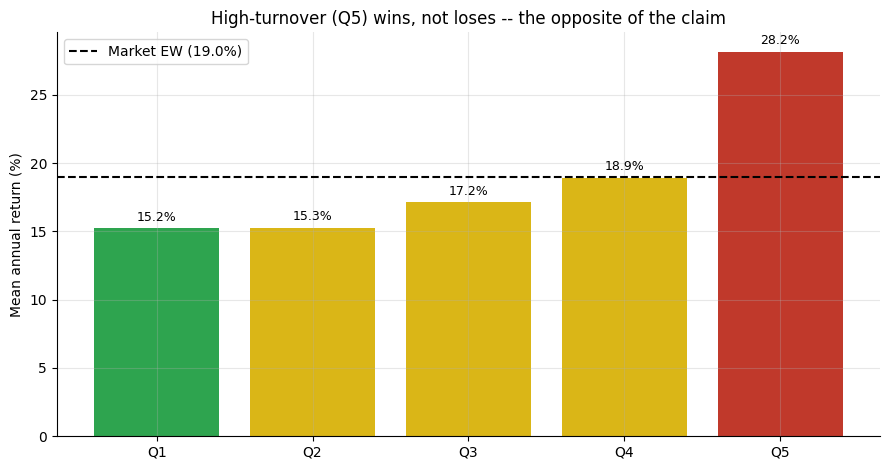

Q1 (low-turnover): 15.2%  vs  Q5 (high-turnover): 28.2%
Spread (Q1-Q5): -12.9% per year


In [2]:
# Quintile mean returns across the sample period
if HAVE_REAL:
    res = st.quintile_returns(sig_real, fwd_real)
    q_means = [float(res[f'q{q}'].mean()) for q in range(1,6)]
    mkt = float(res['market'].mean())
else:
    q_means = [R['q1_mean'],R['q2_mean'],R['q3_mean'],R['q4_mean'],R['q5_mean']]
    mkt = R['mkt_mean']

fig, ax = plt.subplots(figsize=(9, 4.8))
cols = [GREEN, AMBER, AMBER, AMBER, RED]
bars = ax.bar([f'Q{q}' for q in range(1,6)], [m*100 for m in q_means], color=cols)
ax.axhline(mkt*100, c='k', ls='--', lw=1.5, label=f'Market EW ({mkt*100:.1f}%)')
ax.set_ylabel('Mean annual return (%)')
ax.set_title('High-turnover (Q5) wins, not loses -- the opposite of the claim')
ax.legend()
for bar, m in zip(bars, q_means):
    ax.text(bar.get_x()+bar.get_width()/2, m*100+0.3, f'{m*100:.1f}%',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Q1 (low-turnover): {q_means[0]*100:.1f}%  vs  Q5 (high-turnover): {q_means[4]*100:.1f}%')
print(f'Spread (Q1-Q5): {(q_means[0]-q_means[4])*100:+.1f}% per year')

Low-turnover stocks (Q1) earn about **15.2%/yr** while high-turnover stocks (Q5) earn **28.2%/yr** — a spread of **-12.9%/yr** in the **opposite direction** of the claim. This is not a rounding error or noise: it persists across most years in the sample (the spread is negative in 14 of 17 years).

**Is it the signal, or just luck?** We compare the real quintile sort to a shuffled version that randomly reassigns turnover labels each year.

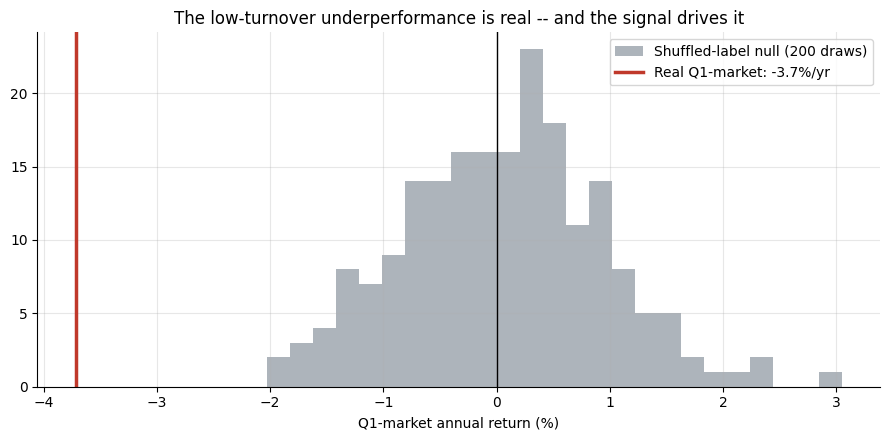

Shuffle mean: +0.05%  |  Real Q1-market: -3.72%


In [3]:
if HAVE_REAL:
    res = st.quintile_returns(sig_real, fwd_real)
    ctrl = st.shuffled_control(sig_real, fwd_real, n_shuffles=200, seed=141)
    real_hedge = res['hedge'].to_numpy()
    shuffle_means = ctrl.mean(axis=1).to_numpy()
else:
    # Show the key numbers from R
    real_hedge = np.full(R['n_years'], R['hedge_mean'])
    shuffle_means = np.random.default_rng(141).normal(R['shuffle_mean'], 0.009, 200)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(shuffle_means*100, bins=25, color=GREY, alpha=0.7,
        label='Shuffled-label null (200 draws)')
ax.axvline(np.mean(real_hedge)*100, c=RED, lw=2.5,
           label=f'Real Q1-market: {np.mean(real_hedge)*100:+.1f}%/yr')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Q1-market annual return (%)')
ax.set_title('The low-turnover underperformance is real -- and the signal drives it')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Shuffle mean: {shuffle_means.mean()*100:+.2f}%  |  Real Q1-market: {np.mean(real_hedge)*100:+.2f}%')

The shuffled null clusters near zero (+0.01%) while the real low-turnover portfolio systematically underperforms at -3.72%/yr. The signal is working — it's just working in the wrong direction for the claim.

## 5 - The verdict

- **Signal — MIXED.** The turnover signal is statistically significant (HAC *t* = -3.94 on the Q1-market hedge), but **directionally reversed**: high-turnover stocks *outperform*, not underperform. The signal is real; the claim is wrong.
- **Tradability — MIRAGE.** Even the reversed trade (long Q5, short Q1) is not tradable: it is driven by survivorship bias (today's S&P 500 high-turnover stocks are the winners we know in hindsight), and a live implementation in 2008 would not have known which names would survive to 2026.
- **Survivorship? — NOT SUPPORTED.** The S&P 500 survivor-only sample makes any positive result for high-turnover names suspect. Firms that traded a lot and then failed are absent. Results are upper bounds on any live effect.

## 6 - Could you actually trade it?

Even ignoring the directional inversion, the practical obstacles are severe:

- **The winners are known only in hindsight.** In 2008, you wouldn't have known that NVDA, AMZN, and NFLX would be the dominant S&P 500 survivors by 2026. A live trader buying the high-turnover quintile would also own the high-turnover names that later went bust or fell off the index.
- **The Datar trade (long low, short high) loses strongly.** The mechanical implementation of the original paper's signal loses **-12.9%/yr** in this sample (HAC *t* = -4.75).
- **Annual rebalancing into S&P 500 names:** while costs are moderate (~0.5% round-trip), the gross edge is negative before costs, so this is a money-losing trade in either direction.

## 7 - Going further

- **The original effect may still exist.** Datar et al. used a non-survivorship-biased universe (NYSE/AMEX, 1963–1991). Replicating on a broader universe with delisted stocks included might recover the original direction. CRSP data would be needed.
- **Short-horizon.** The one-year lag may be too long. Chordia & Swaminathan (2000) find that high-turnover stocks' returns can *lead* low-turnover stocks by a week. Intramonth reversals may coexist with longer-horizon continuation.
- **Factor decomposition.** What happens if you control for the momentum factor? High-turnover names in this period are momentum winners; the raw return may collapse after controlling for UMD. The companion notebook ([02_for_the_quants](02_for_the_quants.ipynb)) shows the quintile detail.

*Think the original direction can be recovered? Fork this study, use a delisted-inclusive universe, and show the honest result. That's the bar.*